In [1]:
from option import BlackScholes
from portfolio import Portfolio
from random import randint, uniform
import numpy as np
import pandas as pd

In [2]:
port_test = Portfolio()

for i in range(1,200): # add 20,000 calls within the Portfolio object
    temp_option = BlackScholes(
        way='c',
        S=uniform(50,250),
        K=uniform(50, 250),
        T=randint(1,3),
        r=uniform(0.02, 0.015),
        sigma=uniform(.2, .55),
        qty=randint(1,2000),
        price=uniform(50, 120))
    port_test.add_underlying(temp_option)

In [3]:
print(f"Overall position of the option book: $ {round(float(port_test.get_option_book_value())/1000000, 2)} M")
print(f"Overall delta of the option book: $ {round(float(port_test.get_delta())/1000000, 2)} M")
print(f"Overall gamma of the option book: $ {round(float(port_test.get_gamma())/1000000, 2)} M")
print(f"Overall vega of the option book: $ {round(float(port_test.get_vega())/1000000, 2)} M")
print(f"Overall rho of the option book: $ {round(float(port_test.get_rho())/1000000, 2)} M")
print(f"Overall theta of the option book: $ {round(float(port_test.get_theta())/1000000, 2)} M")

Overall position of the option book: $ 16.73 M
Overall delta of the option book: $ 9.94 M
Overall gamma of the option book: $ 0.06 M
Overall vega of the option book: $ 7.93 M
Overall rho of the option book: $ 17.15 M
Overall theta of the option book: $ -0.27 M


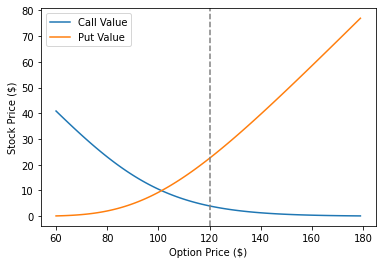

In [7]:
a = BlackScholes(way='c',S=100, K=120, r=0.05, sigma=.5, T=3/12)
a.plot(variable_choice='K')

In [5]:
# Option chain +/- 70% with np.linspace()
# Plot option/stock/portfolios

In [6]:
temp_option = BlackScholes(way='p', S=30, K=40, r=.01, T=240/365, sigma=.3)
temp_option.compute_all()

'value: 10.251133491653508, delta: -0.8494138601511998, gamma: 0.03203161102008452, vega: 0.05686707929045143, rho: -0.23496032413932816, theta: -0.0025751911050726785'

In [8]:
from enum import Enum

class Variables(str, Enum):
    S='S',
    K='K',
    r='r',
    sigma='sigma',
    T='T'

Variables['K']

<Variables.K: 'K'>

## Plot

In [7]:
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline

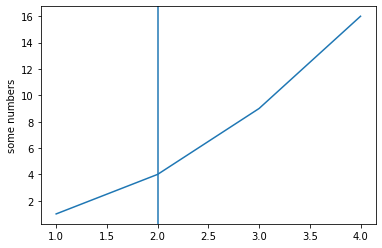

In [8]:
#plt.plot([1, 2, 3, 4])
plt.plot([1, 2, 3, 4], [1, 4, 9, 16])#
plt.ylabel('some numbers')
plt.vlines(2,2,2)
plt.axvline(2,)

plt.show()

In [9]:
np.linspace(1,10,10)

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

/home/zalman/Documents/python/hiram/option.py:48: RuntimeWarning: divide by zero encountered in log
  return (np.log(self.S / self.K) + (self.r - self.q + self.sigma ** 2 / 2) * self.T) / (self.sigma * np.sqrt(self.T))


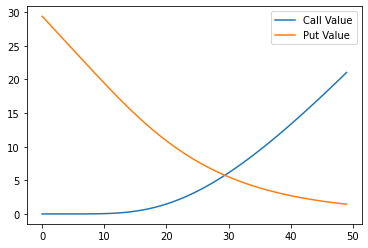

In [10]:
x = np.arange(0, 50)
vals_call = [BlackScholes(way='c', S=x, K=30, r=0.01, sigma=.35, T=2).value() for x in x]
vals_put = [BlackScholes(way='p', S=x, K=30, r=0.01, sigma =.35, T=2).value() for x in x]

plt.plot(x, vals_call, label='Call Value')
plt.plot(x, vals_put, label='Put Value')

plt.legend()

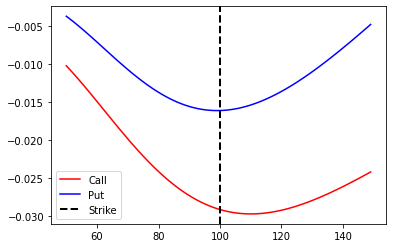

In [ ]:
Sz = np.arange(50, 150)
vals_call = [BlackScholes(way='c', S=100, K=x, r=0.05, sigma =0.45, T=1).theta() for x in Sz]
vals_put = [BlackScholes(way='p', S=100, K=x, r=0.05, sigma =0.45, T=1).theta() for x in Sz]
plt.plot(Sz, vals_call, 'r', label="Call")
plt.plot(Sz, vals_put, 'b', label="Put")
plt.axvline(100, color='black', linestyle='dashed', linewidth=2,label="Strike")

plt.legend()

/home/zalman/Documents/python/hiram/option.py:48: RuntimeWarning: invalid value encountered in scalar divide
  return (np.log(self.S / self.K) + (self.r - self.q + self.sigma ** 2 / 2) * self.T) / (self.sigma * np.sqrt(self.T))


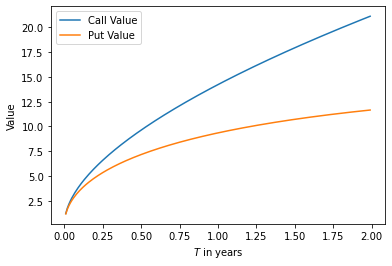

In [ ]:
x = np.arange(0, 2, 0.01)
vals_call = [BlackScholes(way='c', S=100, K=100, r=0.05, sigma=0.3, T=x).value() for x in x]
vals_put = [BlackScholes(way='p', S=100, K=100, r=0.05, sigma =0.3, T=x).value() for x in x]

plt.plot(x, vals_call, label='Call Value')
plt.plot(x, vals_put, label='Put Value')

plt.xlabel('$T$ in years')
plt.ylabel('Value')

plt.legend()